## Données images Apprentissage Automatique

Le modèle utilisé pour la classification binaire (smiling or not) est un ResNet18 pré-entrainé fine tuné sur les données de CelebA. 
Ce choix a été effectué car il nous donnera de meilleur résultat qu'un CNN from scratch.
Cela permettra de se concentré sur les biais du modèle plutot que sont "manque de performance".
Le ResNet18 n'est pas trop lourd ni trop profond pour éviter les overfitting.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from torchvision.models import resnet18
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from lime import lime_image
from skimage.segmentation import mark_boundaries
from smile_cnn_train import CelebADataset, transform_infer, device, CELEBA_DIR

In [ ]:
def load_checkpoint(path, device):
    checkpoint = torch.load(path, weights_only=False)
    model = resnet18()
    model.fc = nn.Linear(512, 1)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint

def get_analysis_indices(checkpoint):
    binary_preds = checkpoint["binary_preds"].squeeze()
    all_labels   = checkpoint["all_labels"].squeeze()
    all_genders  = checkpoint["all_genders"].squeeze()

    correct_mask   = (binary_preds == all_labels)
    incorrect_mask = (binary_preds != all_labels)
    minority_mask  = (all_genders == 1.0)

    idx_correct     = (correct_mask   & (all_genders == 0.0)).nonzero(as_tuple=True)[0][0].item()
    idx_incorrect   = (incorrect_mask & (all_genders == 0.0)).nonzero(as_tuple=True)[0][0].item()
    idx_minoritaire = (incorrect_mask & minority_mask).nonzero(as_tuple=True)[0][0].item()

    return idx_correct, idx_incorrect, idx_minoritaire

In [ ]:
model_saved, checkpoint = load_checkpoint("saved_models/resnet18.pt", device)

idx_correct, idx_incorrect, idx_minoritaire = get_analysis_indices(checkpoint)

In [ ]:
dataset = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=None,
    crop=False
)

Les entrainements étant très long avec un notebook sous Windows (dû à l'impossibilité de faire de la parallélisation avec le CPU pour le traitement des images), ceux-ci on etait réaliser avec un fichier .py annexe. Le code reste globalement le même que celui-ci dessus mais avec un main en plus et de la parallélisation de CPU. 

# Description des résultats

Epoch 1/5 | Train loss: 0.4860 acc: 0.7671 | Val   loss: 0.4580 acc: 0.7830

Epoch 2/5 | Train loss: 0.4506 acc: 0.7888 | Val   loss: 0.4468 acc: 0.7879                

Epoch 3/5 | Train loss: 0.4452 acc: 0.7911 | Val   loss: 0.4392 acc: 0.7966

Epoch 4/5 | Train loss: 0.4424 acc: 0.7937 | Val   loss: 0.4396 acc: 0.7959                 

Epoch 5/5 | Train loss: 0.4409 acc: 0.7943 | Val   loss: 0.4352 acc: 0.7984


Test loss: 0.4388 | Test acc: 0.7947
Modèle sauvegardé dans saved_models\resnet18.pt

# Evaluation de l'équité

Accuracy gap : écart d'accuracy Homme vs Femme
FPR gap : le modèle prédit-il plus souvent "sourit" à tort pour un groupe ?
FNR gap : le modèle rate-t-il plus souvent un sourire pour un groupe ?

In [25]:
def fairness_report(all_preds, all_labels, all_genders):
    binary_preds = (all_preds > 0.5).float()
    groups = {"Femmes": 0.0, "Hommes":1.0}
    accs, fprs, fnrs = {}, {}, {}

    for name, g_vals in groups.items():
        mask = (all_genders == g_vals)
        g_preds = binary_preds[mask]
        g_labels = all_labels[mask]

        acc = (g_preds == g_labels).float().mean().item()
        neg_mask = (g_labels == 0)
        pos_mask = (g_labels == 1)

        fpr = (g_preds[neg_mask] == 1).float().mean().item() if neg_mask.sum() > 0 else float("nan")
        fnr = (g_preds[pos_mask] == 0).float().mean().item() if pos_mask.sum() > 0 else float("nan")
        
        accs[name] = acc
        fprs[name] = fpr
        fnrs[name] = fnr

        n = mask.sum().item()
        print(f"  {name:8s} ({n:6d} imgs) Accuracy: {acc:.4f} FPR: {fpr:.4f} FNR: {fnr:.4f}")

    print(f"\nÉcart Accuracy : {abs(accs['Femmes'] - accs['Hommes']):.4f}")
    print(f"Écart FPR : {abs(fprs['Femmes'] - fprs['Hommes']):.4f}")
    print(f"Écart FNR : {abs(fnrs['Femmes'] - fnrs['Hommes']):.4f}")
    


In [ ]:
fairness_report(checkpoint["all_preds"], checkpoint["all_labels"], checkpoint["all_genders"])

Analyse des résultats :
Accuracy

Femmes : 80.58% vs Hommes : 77.91%
Écart de 2.67% → faible, le modèle performe de façon similaire sur les deux groupes

FPR (False Positive Rate) — prédit "sourit" alors qu'il ne sourit pas

Femmes : 18.52% vs Hommes : 15.61%
Écart de 2.91% → faible, le modèle se trompe légèrement plus sur les femmes

FNR (False Negative Rate) — prédit "ne sourit pas" alors qu'il sourit 

Femmes : 20.16% vs Hommes : 31.46%
Écart de 11.31% → problème significatif !

# Explication post-hoc

## GradCAM

In [ ]:
def affiche_gradcam(cam, model_saved, dataset, dataset_idx, titre):
    row = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil = Image.open(img_path).convert("RGB")
    img_pil = img_pil.resize((224, 224))
    img_np = np.array(img_pil) / 255.0 

    img_tensor = transform_infer(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model_saved(img_tensor).sigmoid().item()

    label = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    targets = [BinaryClassifierOutputTarget(0)]
    grayscale = cam(input_tensor=img_tensor, targets=targets)
    heatmap = show_cam_on_image(img_np.astype(np.float32), grayscale[0], use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(  
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'} "  
        f"Pred: {'Sourit' if pred > 0.5 else 'Ne sourit pas'} ({pred:.2f}) {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("GradCAM")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

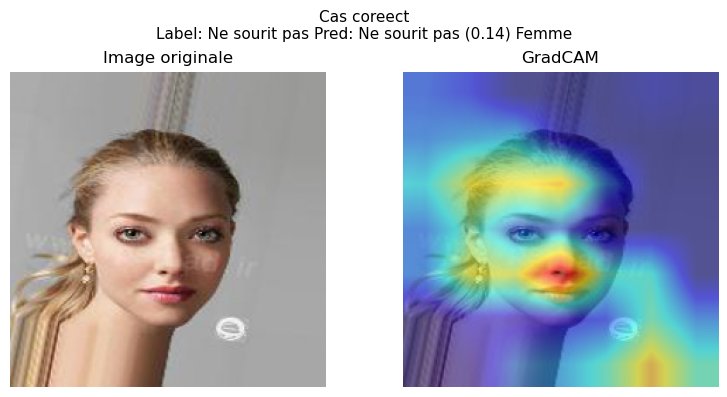

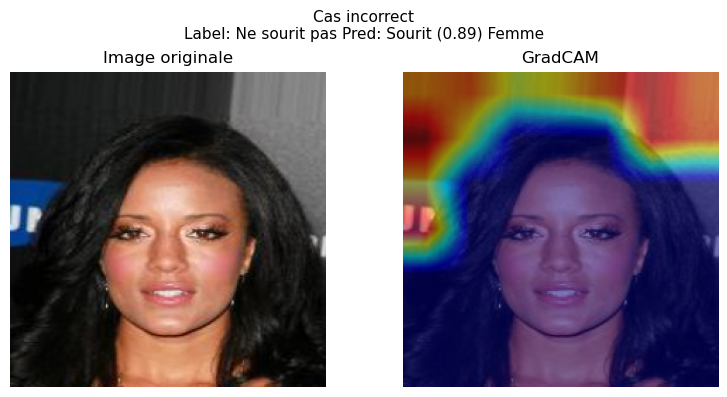

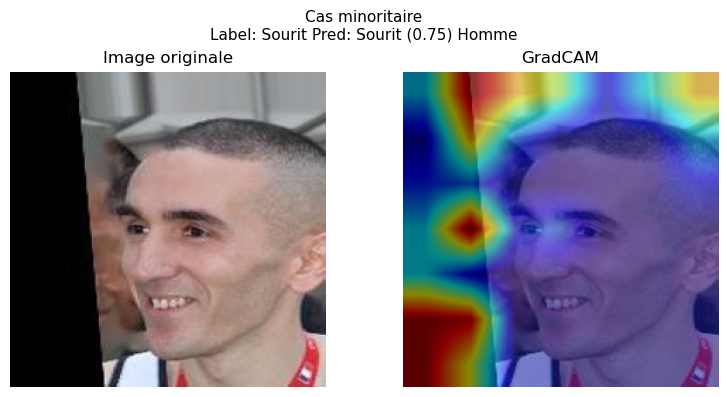

In [ ]:
target_layer = [model_saved.layer4[-1]]
cam = GradCAM(model=model_saved, target_layers=target_layer)

affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_correct],     "Cas correct")
affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_incorrect],   "Cas incorrect")
affiche_gradcam(cam, model_saved, dataset, checkpoint["test_indices"][idx_minoritaire], "Cas minoritaire")

Cas correct 
Le modèle est très confiant (0.02 = loin du seuil 0.5). La heatmap se concentre sur le bas du visage (bouche/joues), c'est exactement la bonne zone pour détecter un sourire. Le modèle a appris le bon concept ici.

Cas incorrect 
Le modèle est très confiant mais faux. La heatmap montre qu'il regarde les cheveux et le fond plutôt que la bouche. Le modèle a probablement été trompé par des corrélats spurieux, peut-être les cheveux longs, le maquillage, ou la luminosité associés aux images de sourire dans CelebA.

Cas minoritaire
Prédit correctement mais la heatmap se concentre sur le crâne/front plutôt que la bouche. Le modèle arrive à la bonne réponse mais pour les mauvaises raisons, ce qui est préoccupant et cohérent avec le FNR élevé chez les hommes (31%).

## LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

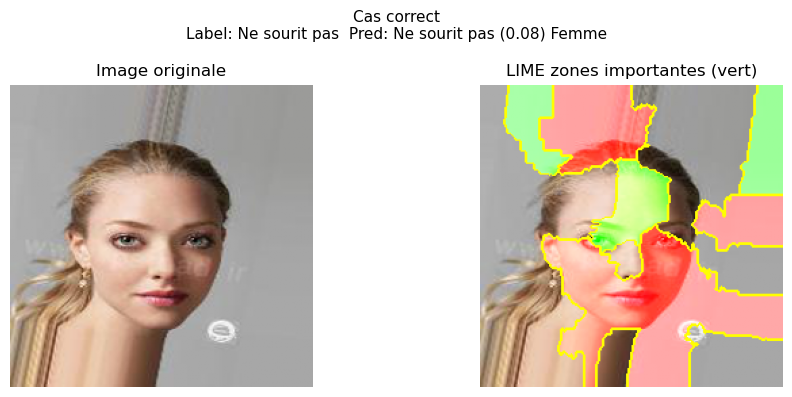

  0%|          | 0/1000 [00:00<?, ?it/s]

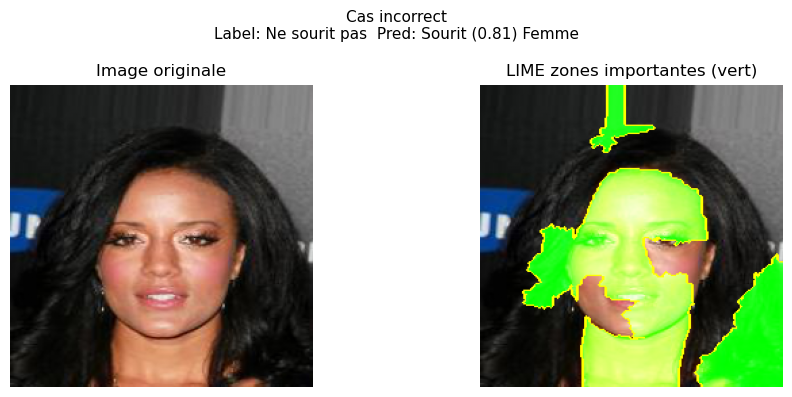

  0%|          | 0/1000 [00:00<?, ?it/s]

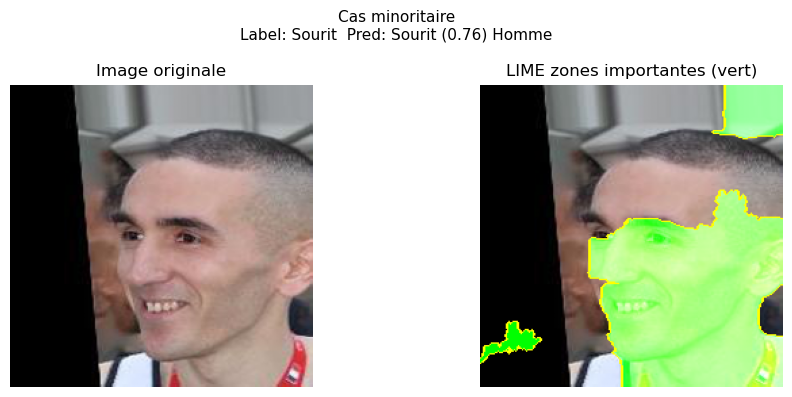

In [ ]:
transform_lime = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def model_predict_lime(model_saved, images_np):
    batch = [
        transform_lime(Image.fromarray((img * 255).astype(np.uint8)))
        for img in images_np
    ]
    batch = torch.stack(batch).to(device)
    with torch.no_grad():
        preds = model_saved(batch).sigmoid().cpu().numpy()
    return np.column_stack([1 - preds, preds])


def afficher_lime(model_saved, dataset, dataset_idx, titre):
    row = dataset.data.iloc[dataset_idx]
    img_path = os.path.join(dataset.img_dir, row["image_id"])
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np = np.array(img_pil) / 255.0 

    label = int((row["Smiling"] + 1) / 2)
    gender = "Homme" if row["Male"] == 1 else "Femme"

    img_tensor = transform_infer(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model_saved(img_tensor).sigmoid().item()


    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np.astype(np.double),
        model_predict_lime,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(
        f"{titre}\nLabel: {'Sourit' if label==1 else 'Ne sourit pas'}  "
        f"Pred: {'Sourit' if pred>0.5 else 'Ne sourit pas'} ({pred:.2f}) {gender}",
        fontsize=11
    )
    axes[0].imshow(img_np)
    axes[0].set_title("Image originale")
    axes[0].axis("off")

    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title("LIME zones importantes (vert)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_correct],     "Cas correct")
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_incorrect],   "Cas incorrect")
afficher_lime(model_saved, dataset, checkpoint["test_indices"][idx_minoritaire], "Cas minoritaire")

Cas correct 
Le modèle regarde les yeux et le haut du visage (vert) pour confirmer l'absence de sourire, et la bouche/lèvres (rouge) comme zone contradictoire. La prédiction est correcte mais le modèle ne se concentre pas uniquement sur la bouche il utilise l'ensemble du visage.

Cas incorrect
Le modèle a été trompé par le visage entier et les cheveux (vert). La zone bouche/menton est en rouge (opposée) paradoxalement la seule zone pertinente est celle que le modèle ignore ! Cela confirme qu'il s'appuie sur des corrélats spurieux comme le teint, le maquillage ou la luminosité.

Cas minoritaire
Le modèle prédit correctement mais regarde surtout le fond et le crâne (vert) plutôt que la bouche. La prédiction est bonne mais pour les mauvaises raisons, ce qui explique pourquoi le modèle échoue souvent sur les hommes (FNR 31%).

Les deux méthodes (GradCAM + LIME) convergent vers la même conclusion — le modèle n'a pas toujours appris le bon concept. Il utilise des caractéristiques non pertinentes comme le fond, les cheveux, ou le teint, ce qui explique les biais observés dans le fairness report, notamment l'écart de FNR de 11% entre hommes et femmes.

# Intervention

## cropper le fond

In [ ]:
model_saved_crop, checkpoint_crop = load_checkpoint("saved_models/resnet18_crop.pt", device)
idx_correct_c, idx_incorrect_c, idx_minoritaire_c = get_analysis_indices(checkpoint_crop)

In [ ]:
dataset_crop = CelebADataset(
    csv_file=os.path.join(CELEBA_DIR, "list_attr_celeba.csv"),
    img_dir=os.path.join(CELEBA_DIR, "img_align_celeba/img_align_celeba"),
    transform=None,
    crop=True
)

In [ ]:
fairness_report(checkpoint_crop["all_preds"], checkpoint_crop["all_labels"], checkpoint_crop["all_genders"])

In [ ]:
target_layer_crop = [model_saved_crop.layer4[-1]]
cam_crop = GradCAM(model=model_saved_crop, target_layers=target_layer_crop)

affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_correct_c],     "Cas correct")
affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_incorrect_c],   "Cas incorrect")
affiche_gradcam(cam_crop, model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_minoritaire_c], "Cas minoritaire")

In [ ]:
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_correct_c],    "Cas correct")
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_incorrect_c],  "Cas incorrect")
afficher_lime(model_saved_crop, dataset_crop, checkpoint_crop["test_indices"][idx_minoritaire_c],"Cas minoritaire")